<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/29MultipleLinearRegressionPracticeProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

# w =[5,10,-2,0.5] , b=2.0
y = np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ])

In [3]:
def make_prediction(X, W, b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in  range(m):
    pred_list[i] = np.dot(W,X[i]) + b

  return pred_list

In [4]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

In [5]:
def compute_cost(X, y, W, b):
  m = X.shape[0]
  cost = 0.0

  pred_list = make_prediction(X, W, b)
  # print(pred_list)

  error = pred_list - y
  # print(error)

  error_squared = error ** 2
  cost = np.sum(error_squared)

  cost = cost / (2*m)

  return cost

In [6]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X,y, W_init ,b_init)

np.float64(3060.2095)

In [7]:
def calculate_gradient(X, y, W, b):
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    prediction = np.dot(W, X[i]) + b
    # print(f"prediction: {prediction}")
    error = prediction - y[i]
    # print(f'error: {error}')

    dj_db = dj_db + error
    # print(f'dj_db: {dj_db}')

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])
      # print(f'dj_dw{i, j}: {dj_dw}')

  return dj_dw / m, dj_db /m

In [8]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X,y, W_init ,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

In [9]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient

    w = w - alpha * dj_dw
    b = b - alpha * dj_db



    # 3. Track progress by saving the cost
    cost = compute_cost(X,y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [10]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=10000, alpha=0.01)

Iteration 0: Cost 188.4458,dj_dw: [-416.09  -660.91   -57.608 -299.43 ] ,dj_db : -90.14 w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977,dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154] ,dj_db : 0.08612436152810546 w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303,dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368] ,dj_db : 0.007027042739051126 w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229,dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236] ,dj_db : 0.001434162447482379 w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162,dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ] ,dj_db : 0.0010265453320016603 w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098,dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513] ,dj_db : 0.0009845325017138861 w: [ 6.7392106   8.50700022 -0.561278

Q1. Feature & Target বিশ্লেষণ করো Kaggle এর Salary Prediction Dataset লোড করো। Years of Experience , Age, Education Level — এই তিনটি feature এবং Salary target এর মধ্যে relationship বোঝার জন্য:

প্রতিটি feature এর বিপরীতে Salary এর scatter plot আঁকো

correlation matrix বের করো

কোন feature টি সবচেয়ে strongly linear সেটা লিখে জানাও


In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('/content/Salary Data.csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [13]:
df.dropna(subset = ['Education Level'], inplace = True)

In [14]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

In [15]:
from sklearn.preprocessing import OrdinalEncoder

eduacation_level_encoder = OrdinalEncoder(categories=[["Bachelor's", "Master's", 'PhD']])

eduacation_level_encoder.fit(df[['Education Level']])

df['encoded_education_level'] = eduacation_level_encoder.transform(df[['Education Level']]).ravel()

In [16]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,encoded_education_level
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,0.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,1.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,2.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0.0
4,52.0,Male,Master's,Director,20.0,200000.0,1.0
...,...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0,0.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0,1.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0,0.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0,0.0


In [17]:
features = ['Years of Experience', 'Age', 'encoded_education_level']
target = 'Salary'

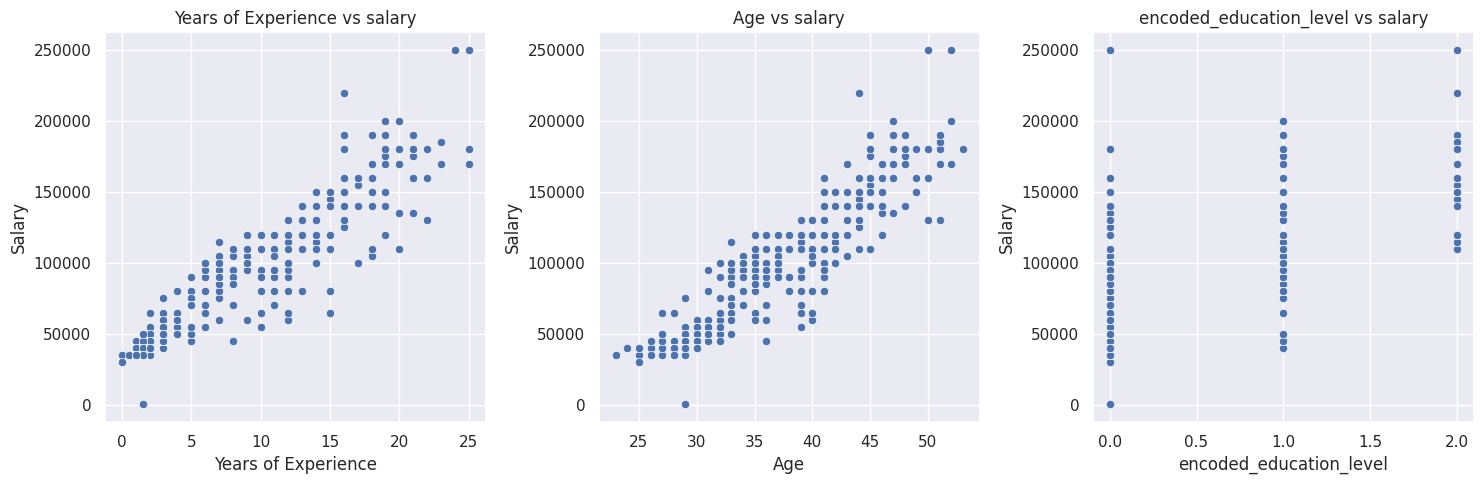

In [18]:
plt.figure(figsize = (15, 5))

for i, feature in enumerate(features):
  plt.subplot(1, 3, i+1)
  sns.scatterplot(data = df, x = feature, y = target)
  plt.title(f'{feature} vs salary')
  plt.xlabel(feature)
  plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [19]:
numerical_cols = ['Years of Experience', 'Age', 'encoded_education_level', 'Salary']
correlation_matrix = df[numerical_cols].corr()

print(correlation_matrix)

                         Years of Experience       Age  \
Years of Experience                 1.000000  0.979128   
Age                                 0.979128  1.000000   
encoded_education_level             0.590863  0.562693   
Salary                              0.930338  0.922335   

                         encoded_education_level    Salary  
Years of Experience                     0.590863  0.930338  
Age                                     0.562693  0.922335  
encoded_education_level                 1.000000  0.670371  
Salary                                  0.670371  1.000000  


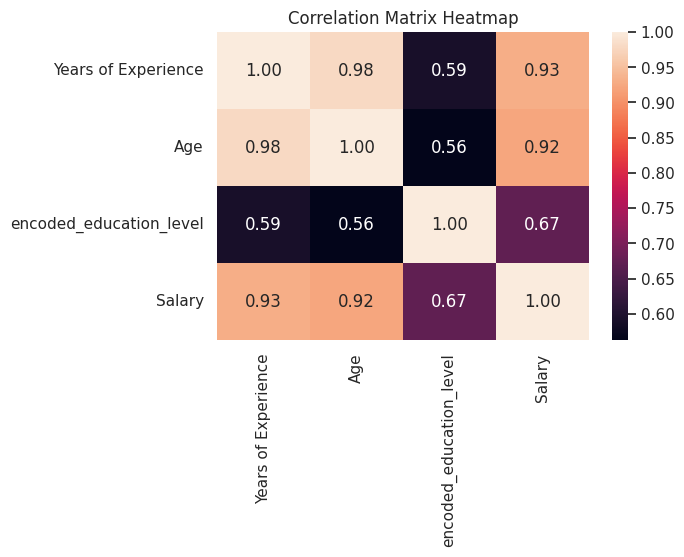

In [20]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

Years of experience and Age column strongly linear

Q2. NumPy দিয়ে Prediction Function লেখো নিচের data manually define করো (অন্তত ১০টি row, ৩টি feature):

Feature: study_hours, sleep_hours, attendance_pct → Target: exam_score
NumPy ব্যবহার করে:

predict(X, w, b) function লেখো যেখানে y_pred = X @ w + b

Random weights দিয়ে সব rows এর prediction করো এবং actual values এর সাথে পাশাপাশি print করো


In [21]:
X = np.array([
    [5.0, 7.5, 85.0],
    [3.2, 6.0, 70.0],
    [7.5, 8.0, 95.0],
    [1.5, 5.5, 60.0],
    [6.0, 7.0, 90.0],
    [4.5, 6.5, 78.0],
    [2.0, 8.0, 65.0],
    [8.0, 7.5, 98.0],
    [5.5, 6.0, 82.0],
    [4.0, 7.0, 75.0]
])

y_actual = np.array([78, 62, 93, 45, 85, 74, 55, 97, 80, 70])

In [22]:
np.random.seed(42)
W = np.random.randn(3)
b = np.random.randn()

In [23]:
predicted_value = make_prediction(X, W, b)

In [24]:
for actual, pred in  zip(y_actual, predicted_value):
  print(f'Actual value: {actual}, Predicted value: {pred}')

Actual value: 78, Predicted value: 58.02314410123916
Actual value: 62, Predicted value: 47.621127006065336
Actual value: 93, Predicted value: 65.67268271418858
Actual value: 45, Predicted value: 40.36895971552491
Actual value: 85, Predicted value: 61.82743309533945
Actual value: 74, Predicted value: 53.37923155919989
Actual value: 55, Predicted value: 43.51009872960603
Actual value: 97, Predicted value: 67.93323755558187
Actual value: 80, Predicted value: 56.535832015199475
Actual value: 70, Predicted value: 51.1186767178066


Q3. Scikit-learn দিয়ে প্রথম Multiple Linear Regression (MLR) Model sklearn.datasets.fetch_california_housing() লোড করো।

MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও

LinearRegression দিয়ে model train করো

coef_ এবং intercept_ print করো

যেকোনো ৫টি sample এর predicted vs actual value দেখাও


In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [26]:
california = fetch_california_housing(as_frame=True)
df = california.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [27]:
features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[features]
y = df['MedHouseVal']

In [28]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [29]:
print(f'coeficient: {model.coef_}')
print(f'intercept: {model.intercept_}')

coeficient: [ 0.4427634  -0.02715343  0.01682208]
intercept: 0.020406956964582168


In [30]:
X_test = X.head(5)
y_actual = y.head(5).values

In [31]:
y_predict = model.predict(X_test)

for actual, pred in zip(y_actual, y_predict):
  print(f'Actual: {actual}, prediction {pred}')

Actual: 4.526, prediction 4.206563077164015
Actual: 3.585, prediction 3.8798398883248844
Actual: 3.521, prediction 3.88341489382408
Actual: 3.413, prediction 3.235752205438251
Actual: 3.422, prediction 2.427537839153152


Q4. MSE Cost Function implement ও visualize করো Q2 এর data ব্যবহার করো।

NumPy দিয়ে MSE cost function লেখো: J = (1/2m) * sum((y_pred - y)^2)

w[0] কে -10 থেকে +10 এর মধ্যে vary করো, বাকি weights fixed রাখো

Cost এর change একটি line plot এ দেখাও এবং minimum কোথায় সেটা mark করো


In [32]:
X = np.array([
    [5.0, 7.5, 85.0], [3.2, 6.0, 70.0], [7.5, 8.0, 95.0],
    [1.5, 5.5, 60.0], [6.0, 7.0, 90.0], [4.5, 6.5, 78.0],
    [2.0, 8.0, 65.0], [8.0, 7.5, 98.0], [5.5, 6.0, 82.0],
    [4.0, 7.0, 75.0]
])
y = np.array([85, 65, 92, 50, 88, 75, 58, 96, 78, 70])

In [33]:
w_fixed = np.array([0.5, 0.2, 0.1])
b_fixed = 0.5

w0_vals = np.linspace(-10, 10, 100)
costs = []

In [34]:
for w0 in w0_vals:
    w_current = w_fixed.copy()
    w_current[0] = w0 # w[0] পরিবর্তন করা হচ্ছে
    cost = compute_cost(X, y, w_current, b_fixed)
    costs.append(cost)

costs = np.array(costs)

In [35]:
min_idx = np.argmin(costs)
best_w0 = w0_vals[min_idx]
min_cost = costs[min_idx]

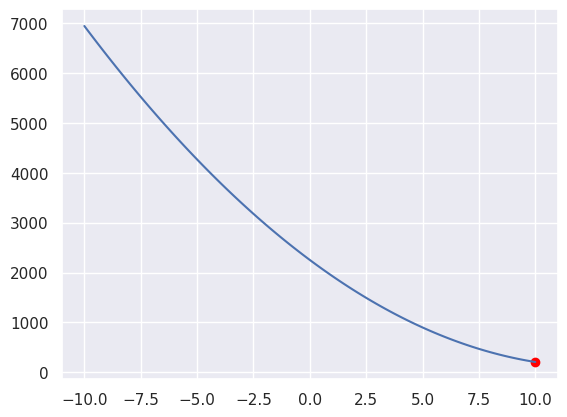

In [36]:
plt.plot(w0_vals, costs)
plt.scatter(best_w0, min_cost, color = 'red')
plt.show()

In [37]:
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)
df

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [38]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [39]:
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first few rows of the scaled features to verify
print("Scaled X (first 5 rows):")
print(X_scaled[:5])

Scaled X (first 5 rows):
[[ 0.96985227  0.98152247  1.77894547]
 [-1.19737623  1.08280781  0.66957876]
 [-1.51615499  1.52846331  1.78354865]
 [ 0.05204968  1.21785493  1.28640506]
 [ 0.3941822  -0.84161366  1.28180188]]


In [41]:
n = X_scaled.shape[1]
W_init = np.zeros((n,))
b_init = 0.0

In [42]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X_scaled, y, w_input=W_init, b_input=b_init, max_iter=1000, alpha=0.01)

Iteration 0: Cost 109.6334,dj_dw: [-4.07100612 -2.9988908  -1.18815867] ,dj_db : -14.022500000000003 w: [0.04071006 0.02998891 0.01188159], b: 0.1402
Iteration 100: Cost 15.7476,dj_dw: [-1.42232363 -0.94193715  0.00849317] ,dj_db : -5.13268850550386 w: [2.54182891 1.77635654 0.42770435], b: 8.9411
Iteration 200: Cost 3.3457,dj_dw: [-0.50625347 -0.34425966  0.15405   ] ,dj_db : -1.8787299906957775 w: [3.42287994 2.35944301 0.3127875 ], b: 12.1626
Iteration 300: Cost 1.6663,dj_dw: [-0.18272475 -0.14615512  0.11491833] ,dj_db : -0.6876759371146081 w: [3.73843171 2.58714537 0.17465678], b: 13.3417
Iteration 400: Cost 1.4324,dj_dw: [-0.06663474 -0.06919131  0.06752374] ,dj_db : -0.25171163329932383 w: [3.85285142 2.68897003 0.08485972], b: 13.7733
Iteration 500: Cost 1.3985,dj_dw: [-0.02448568 -0.0348403   0.03672916] ,dj_db : -0.092134598462257 w: [3.89471947 2.73868989 0.03424984], b: 13.9313
Iteration 600: Cost 1.3932,dj_dw: [-0.00904969 -0.01806051  0.01939721] ,dj_db : -0.0337242427874

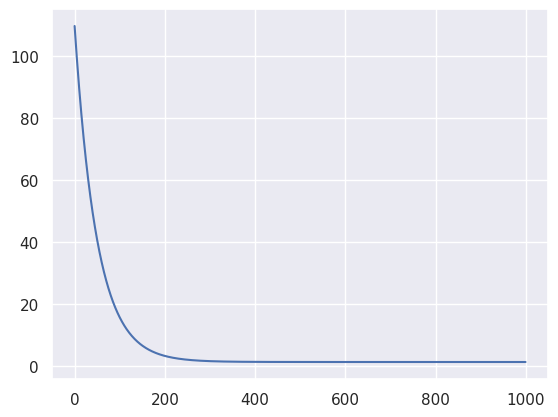

In [44]:
plt.plot(iter_list, cost_memo)
plt.show()

Q6. LinearRegression vs SGDRegressor তুলনা Energy Efficiency dataset (UCI) থেকে heating load predict করো।

LinearRegression এবং SGDRegressor দুটোই একই data তে train করো

দুটোর learned weights ও MSE পাশাপাশি একটি table এ দেখাও

২-৩ লাইনে লেখো কেন SGDRegressor এর weights exact match করে না

Covers: Scikit-learn SGDRegressor, why results differ


In [45]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [47]:
df = pd.read_excel('/content/ENB2012_data.xlsx')
df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [48]:
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y = df['Y1'].values

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred_lr = lr.predict(X_scaled)

In [51]:
sgd = SGDRegressor(max_iter=5000, tol=1e-4, random_state=42)
sgd.fit(X_scaled, y)
y_pred_sgd = sgd.predict(X_scaled)

In [52]:
mse_lr = mean_squared_error(y, y_pred_lr)
mse_sgd = mean_squared_error(y, y_pred_sgd)

In [53]:
weights_data = {
    'LinearRegression': list(lr.coef_) + [lr.intercept_, mse_lr],
    'SGDRegressor': list(sgd.coef_) + [sgd.intercept_[0], mse_sgd]
}

In [54]:
df_comparison = pd.DataFrame(weights_data)
df_comparison

,LinearRegression,SGDRegressor
0,-6.847108,-3.483826
1,-3.766967,-1.390698
2,0.711360,1.240828
3,-4.016872,-1.955390
4,7.297419,8.378725
5,-0.026084,-0.021415
6,2.653721,2.659869
7,0.315844,0.318149
8,22.307195,22.302151
9,8.520534,8.629248


In [55]:
weights_data = {
    'Parameter': [f'Weight (X{i})' for i in range(1, 9)] + ['Intercept (Bias)', 'Model MSE'],
    'LinearRegression': list(lr.coef_) + [lr.intercept_, mse_lr],
    'SGDRegressor': list(sgd.coef_) + [sgd.intercept_[0], mse_sgd]
}

In [56]:
df_comparison = pd.DataFrame(weights_data)
df_comparison

,Parameter,LinearRegression,SGDRegressor
0,Weight (X1),-6.847108,-3.483826
1,Weight (X2),-3.766967,-1.390698
2,Weight (X3),0.711360,1.240828
3,Weight (X4),-4.016872,-1.955390
4,Weight (X5),7.297419,8.378725
5,Weight (X6),-0.026084,-0.021415
6,Weight (X7),2.653721,2.659869
7,Weight (X8),0.315844,0.318149
8,Intercept (Bias),22.307195,22.302151
9,Model MSE,8.520534,8.629248
